First 5 Rows
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Shape:
(200, 5)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+

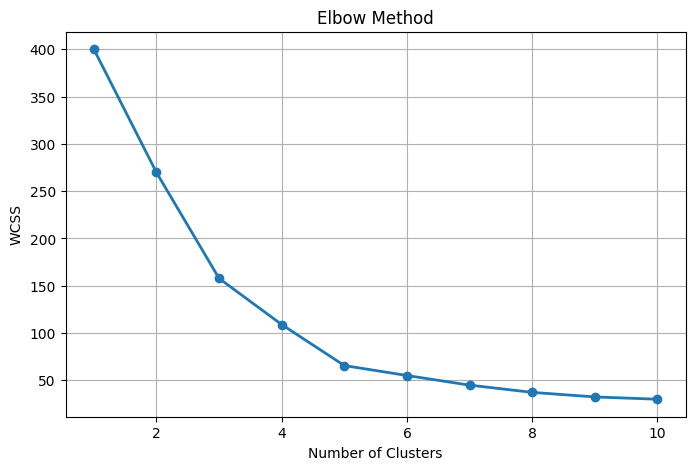


Clustered Dataset
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  

Cluster Centers
Cluster 0:
Annual Income = 55.30
Spending Score = 49.52

Cluster 1:
Annual Income = 86.54
Spending Score = 82.13

Cluster 2:
Annual Income = 25.73
Spending Score = 79.36

Cluster 3:
Annual Income = 88.20
Spending Score = 17.11

Cluster 4:
Annual Income = 26.30
Spending Score = 20.91



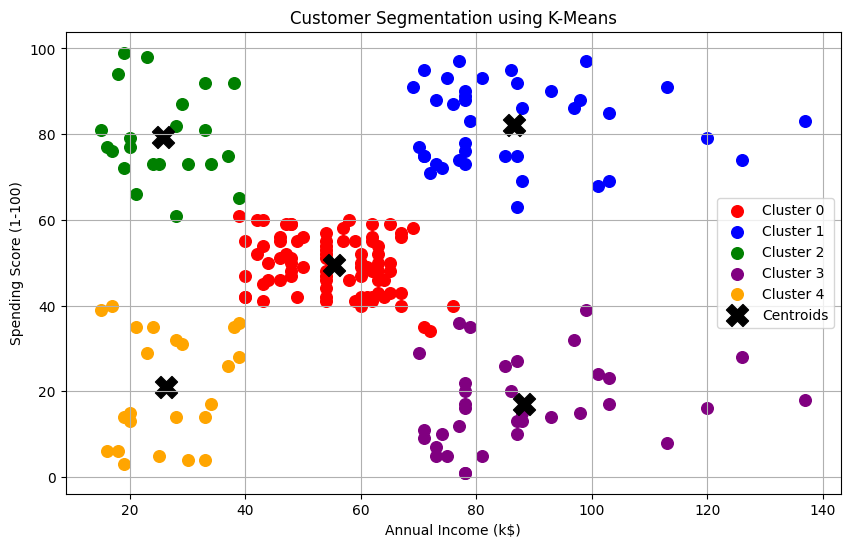


Customers in Each Cluster
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

Cluster Summary
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043

Output saved as 'Customer_Segmentation_Output.csv'

Cluster Interpretation
Cluster 0 : Budget Customers (Low Income, Low Spending)
Cluster 1 : Premium Customers (High Income, High Spending)
Cluster 2 : Careful Customers (High Income, Low Spending)
Cluster 3 : Impulsive Customers (Low Income, High Spending)
Cluster 4 : Average Customers (Medium Income, Medium Spending)

Project Completed Successfully!


In [ ]:
# Mall Customer Segmentation using K-Means
# SkillCraft Technology - Task 02
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Loading Dataset
df = pd.read_csv("/content/Mall_Customers.csv")

# Dataset Information
print("=" * 50)
print("First 5 Rows")
print("=" * 50)
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

# Features for Clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method
wcss = []

for i in range(1, 11):
    model = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42,
        n_init=10
    )
    model.fit(X_scaled)
    wcss.append(model.inertia_)

# Plot Elbow Method
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o', linewidth=2)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

# KMeans Model
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

# Cluster Labels
df['Cluster'] = clusters

# Clustered Dataset
print("\nClustered Dataset")
print(df.head())

# Cluster Centers
centers = scaler.inverse_transform(kmeans.cluster_centers_)

print("\nCluster Centers")
for i, center in enumerate(centers):
    print(f"Cluster {i}:")
    print(f"Annual Income = {center[0]:.2f}")
    print(f"Spending Score = {center[1]:.2f}")
    print()

# Scatter Plot of Customer Segments
plt.figure(figsize=(10,6))

colors = ['red', 'blue', 'green', 'purple', 'orange']

for i in range(5):
    plt.scatter(
        df[df['Cluster'] == i]['Annual Income (k$)'],
        df[df['Cluster'] == i]['Spending Score (1-100)'],
        s=70,
        color=colors[i],
        label=f'Cluster {i}'
    )

# Plotting Centroids
plt.scatter(
    centers[:,0],
    centers[:,1],
    s=250,
    c='black',
    marker='X',
    label='Centroids'
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.grid(True)
plt.show()

# Customers in Each Cluster
print("\nCustomers in Each Cluster")
print(df['Cluster'].value_counts().sort_index())

# Cluster Summary
summary = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

print("\nCluster Summary")
print(summary)

# Save Output
df.to_csv("Customer_Segmentation_Output.csv", index=False)

print("\nOutput saved as 'Customer_Segmentation_Output.csv'")

# Cluster Interpretation
print("\nCluster Interpretation")

print("Cluster 0 : Budget Customers (Low Income, Low Spending)")
print("Cluster 1 : Premium Customers (High Income, High Spending)")
print("Cluster 2 : Careful Customers (High Income, Low Spending)")
print("Cluster 3 : Impulsive Customers (Low Income, High Spending)")
print("Cluster 4 : Average Customers (Medium Income, Medium Spending)")

print("\nProject Completed Successfully!")